In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as  sns

In [2]:
df = pd.read_csv('allmvpstats.csv')

In [4]:
df.head()

,season,player,team,award,age,winner,per,ws_48,bpm,vorp,...,blocks,rebounds,w,l,win%,fg_per_game,3pm,2pm,ft_percent,tov_per_game
0,2024,Nikola Jokic,DEN,nba mvp,28,True,31.0,0.299,13.2,10.6,...,0.9,12.4,57.0,25.0,0.6951,10.4,1.1,9.4,0.817,3.0
1,2024,Shai Gilgeous-Alexander,OKC,nba mvp,25,False,29.3,0.275,9.0,7.1,...,0.9,5.5,57.0,25.0,0.6951,10.6,1.3,9.3,0.874,2.2
2,2024,Luka Doncic,DAL,nba mvp,24,False,28.1,0.220,9.9,8.0,...,0.5,9.2,50.0,32.0,0.6098,11.5,4.1,7.4,0.786,4.0
3,2024,Giannis Antetokounmpo,MIL,nba mvp,29,False,29.9,0.246,9.0,7.2,...,1.1,11.5,49.0,33.0,0.5976,11.5,0.5,11.0,0.657,3.4
4,2024,Jalen Brunson,NYK,nba mvp,27,False,23.4,0.198,5.8,5.4,...,0.2,3.6,50.0,32.0,0.6098,10.3,2.7,7.5,0.847,2.4


In [5]:
df.tail()

,season,player,team,award,age,winner,per,ws_48,bpm,vorp,...,blocks,rebounds,w,l,win%,fg_per_game,3pm,2pm,ft_percent,tov_per_game
1040,1956,Mel Hutchins,NaN,nba mvp,27,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1041,1956,Dolph Schayes,NaN,nba mvp,27,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1042,1956,Bill Sharman,NaN,nba mvp,29,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1043,1956,Tom Gola,NaN,nba mvp,23,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1044,1956,Maurice Stokes,NaN,nba mvp,22,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Player stats from older generations are missing

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1045 entries, 0 to 1044
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   season        1045 non-null   int64  
 1   player        1045 non-null   object 
 2   team          519 non-null    object 
 3   award         1045 non-null   object 
 4   age           1045 non-null   int64  
 5   winner        1045 non-null   bool   
 6   per           430 non-null    float64
 7   ws_48         430 non-null    float64
 8   bpm           430 non-null    float64
 9   vorp          430 non-null    float64
 10  ppg           519 non-null    float64
 11  assists       519 non-null    float64
 12  steals        519 non-null    float64
 13  blocks        519 non-null    float64
 14  rebounds      519 non-null    float64
 15  w             517 non-null    float64
 16  l             517 non-null    float64
 17  win%          517 non-null    float64
 18  fg_per_game   519 non-null  

In [8]:
# csv has stats of players from 1996 and up

In [3]:
df_new = df[df['season'] >= 1996]

In [10]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 425 entries, 0 to 424
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   season        425 non-null    int64  
 1   player        425 non-null    object 
 2   team          414 non-null    object 
 3   award         425 non-null    object 
 4   age           425 non-null    int64  
 5   winner        425 non-null    bool   
 6   per           425 non-null    float64
 7   ws_48         425 non-null    float64
 8   bpm           425 non-null    float64
 9   vorp          425 non-null    float64
 10  ppg           414 non-null    float64
 11  assists       414 non-null    float64
 12  steals        414 non-null    float64
 13  blocks        414 non-null    float64
 14  rebounds      414 non-null    float64
 15  w             412 non-null    float64
 16  l             412 non-null    float64
 17  win%          412 non-null    float64
 18  fg_per_game   414 non-null    float

In [11]:
df_new.isnull().sum()

season           0
player           0
team            11
award            0
age              0
winner           0
per              0
ws_48            0
bpm              0
vorp             0
ppg             11
assists         11
steals          11
blocks          11
rebounds        11
w               13
l               13
win%            13
fg_per_game     11
3pm             11
2pm             11
ft_percent      11
tov_per_game    11
dtype: int64

In [4]:
# Use KNNImputer on remaining null values to maintain relationships between features
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_new_imputed = pd.DataFrame(imputer.fit_transform(df_new.select_dtypes(include=['number'])),
                              columns=df_new.select_dtypes(include=['number']).columns)

In [10]:
df_new_imputed.isna().sum().sum()

0

In [13]:
df_new_imputed.head()

,season,age,per,ws_48,bpm,vorp,ppg,assists,steals,blocks,rebounds,w,l,win%,fg_per_game,3pm,2pm,ft_percent,tov_per_game
0,2024.0,28.0,31.0,0.299,13.2,10.6,26.4,9.0,1.4,0.9,12.4,57.0,25.0,0.6951,10.4,1.1,9.4,0.817,3.0
1,2024.0,25.0,29.3,0.275,9.0,7.1,30.1,6.2,2.0,0.9,5.5,57.0,25.0,0.6951,10.6,1.3,9.3,0.874,2.2
2,2024.0,24.0,28.1,0.220,9.9,8.0,33.9,9.8,1.4,0.5,9.2,50.0,32.0,0.6098,11.5,4.1,7.4,0.786,4.0
3,2024.0,29.0,29.9,0.246,9.0,7.2,30.4,6.5,1.2,1.1,11.5,49.0,33.0,0.5976,11.5,0.5,11.0,0.657,3.4
4,2024.0,27.0,23.4,0.198,5.8,5.4,28.7,6.7,0.9,0.2,3.6,50.0,32.0,0.6098,10.3,2.7,7.5,0.847,2.4


In [5]:
df_final = pd.concat([df_new_imputed, df_new['winner']], axis=1)

In [6]:
df_final.head()

,season,age,per,ws_48,bpm,vorp,ppg,assists,steals,blocks,rebounds,w,l,win%,fg_per_game,3pm,2pm,ft_percent,tov_per_game,winner
0,2024.0,28.0,31.0,0.299,13.2,10.6,26.4,9.0,1.4,0.9,12.4,57.0,25.0,0.6951,10.4,1.1,9.4,0.817,3.0,True
1,2024.0,25.0,29.3,0.275,9.0,7.1,30.1,6.2,2.0,0.9,5.5,57.0,25.0,0.6951,10.6,1.3,9.3,0.874,2.2,False
2,2024.0,24.0,28.1,0.220,9.9,8.0,33.9,9.8,1.4,0.5,9.2,50.0,32.0,0.6098,11.5,4.1,7.4,0.786,4.0,False
3,2024.0,29.0,29.9,0.246,9.0,7.2,30.4,6.5,1.2,1.1,11.5,49.0,33.0,0.5976,11.5,0.5,11.0,0.657,3.4,False
4,2024.0,27.0,23.4,0.198,5.8,5.4,28.7,6.7,0.9,0.2,3.6,50.0,32.0,0.6098,10.3,2.7,7.5,0.847,2.4,False


In [11]:
print('Number of duplicates:', df_new_imputed.duplicated().sum())

Number of duplicates: 0


In [70]:
df_final['winner'].value_counts()

winner
False    396
True      29
Name: count, dtype: int64

In [ ]:
# Very small sample of winners

In [18]:
numerical_cols = df_final.select_dtypes(include=['number']).columns.tolist()

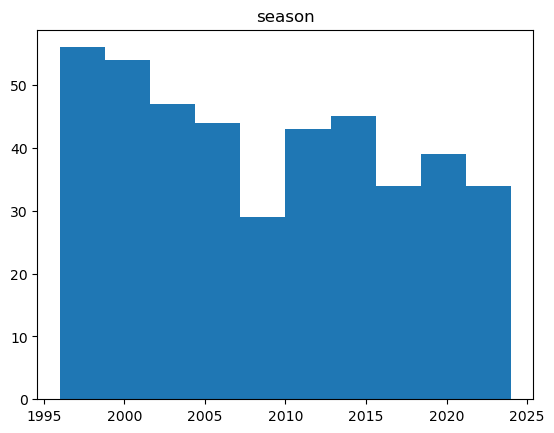

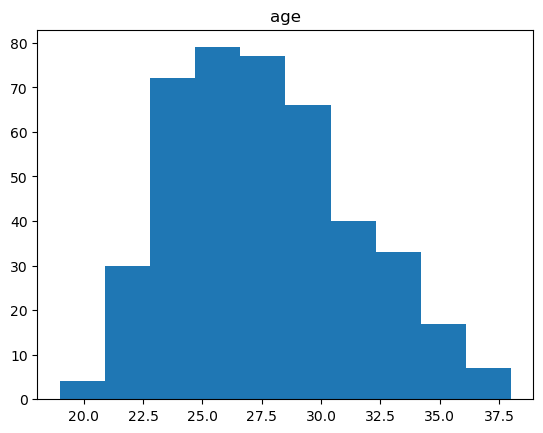

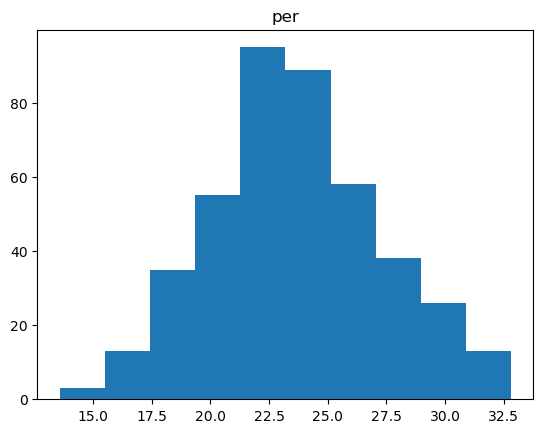

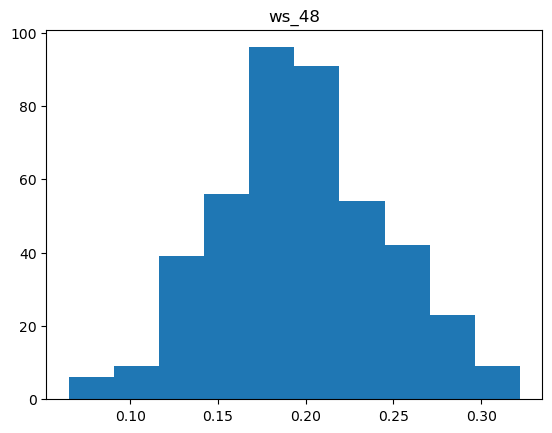

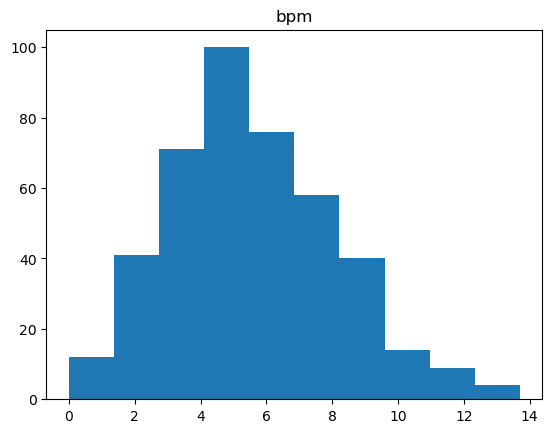

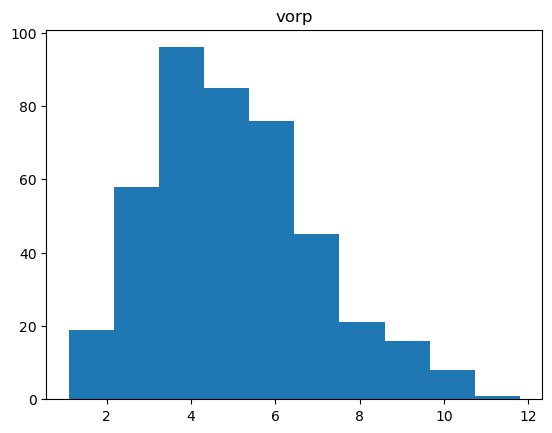

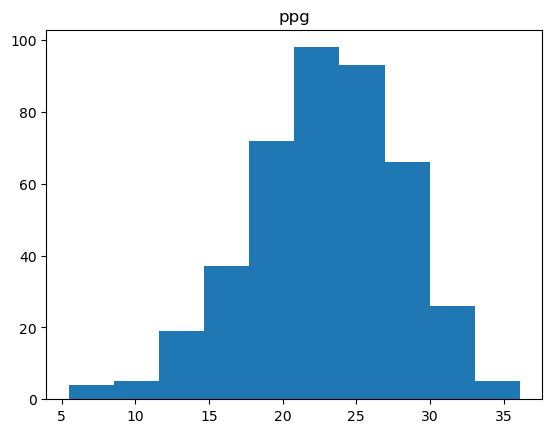

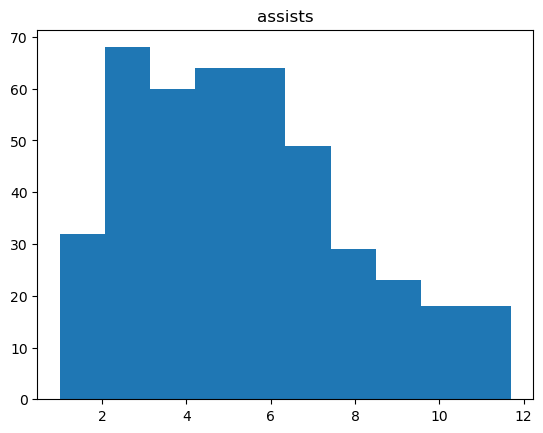

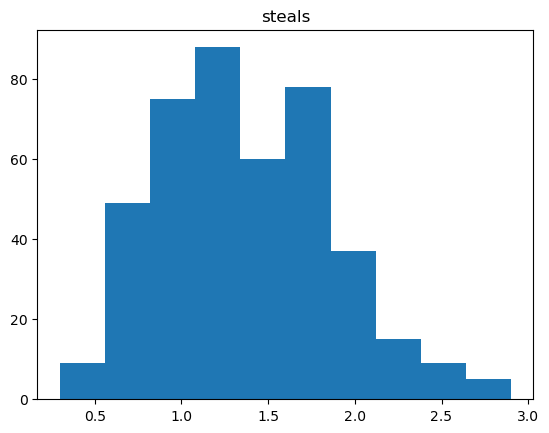

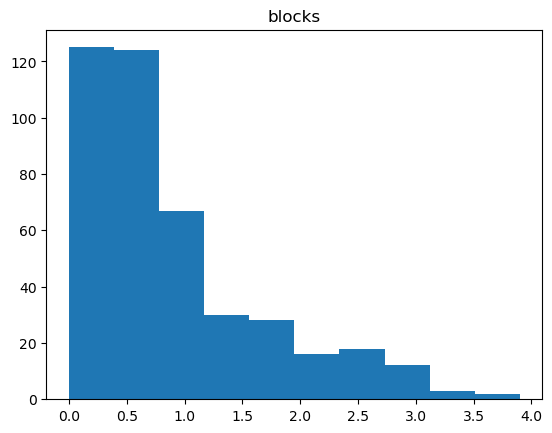

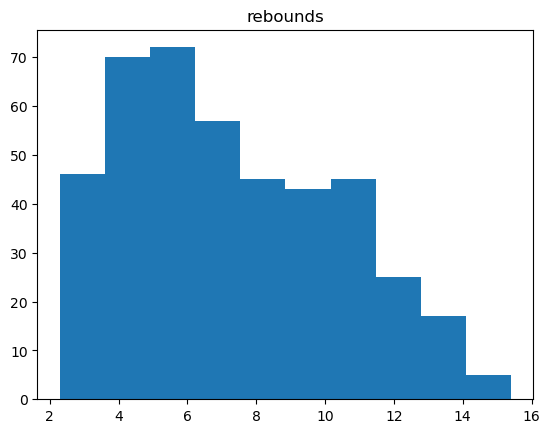

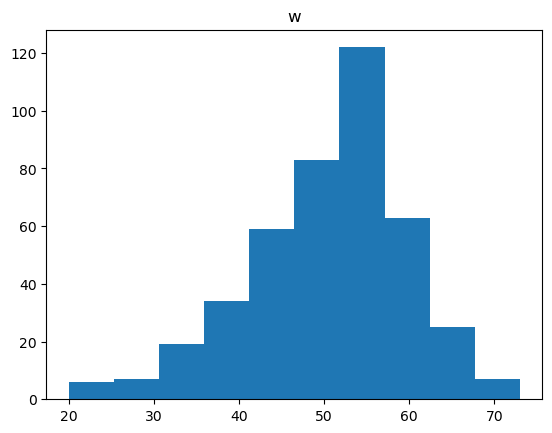

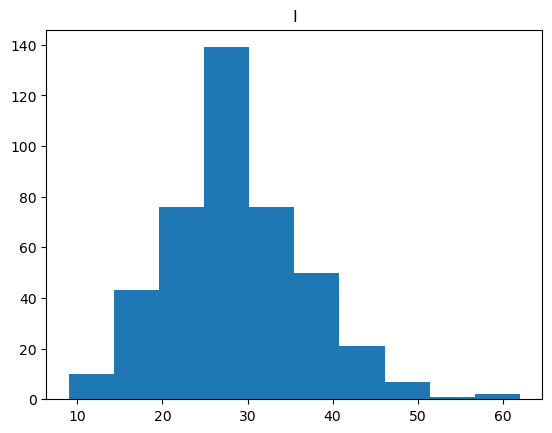

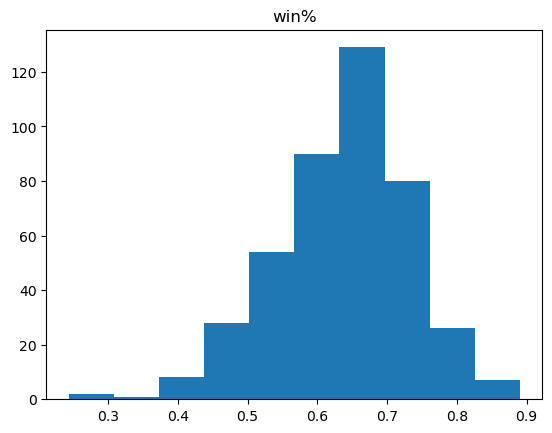

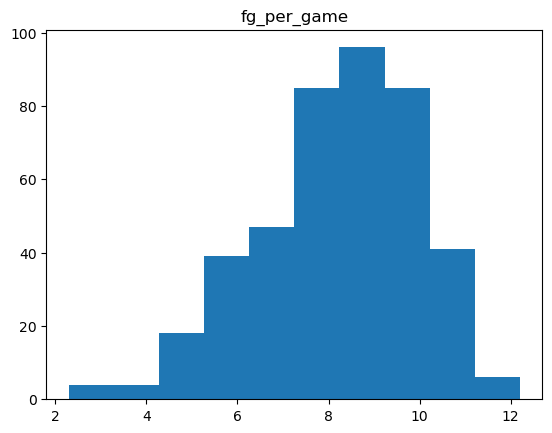

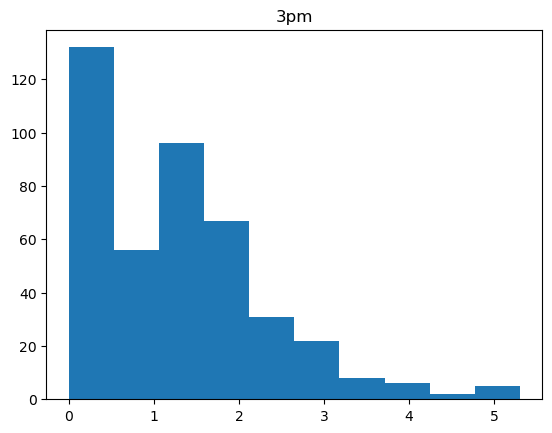

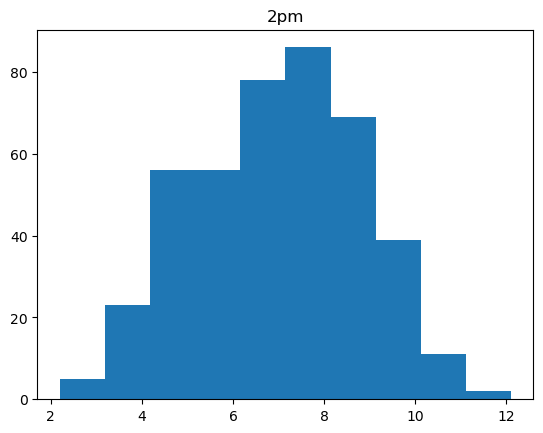

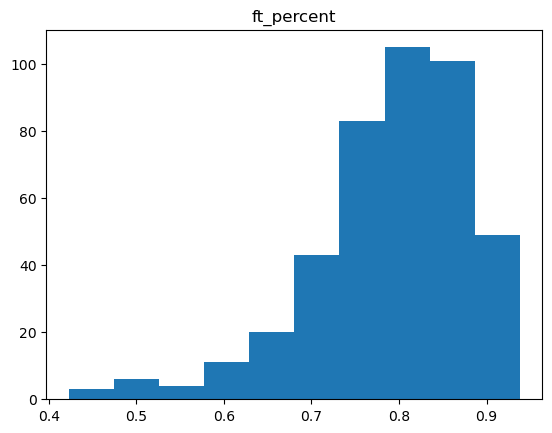

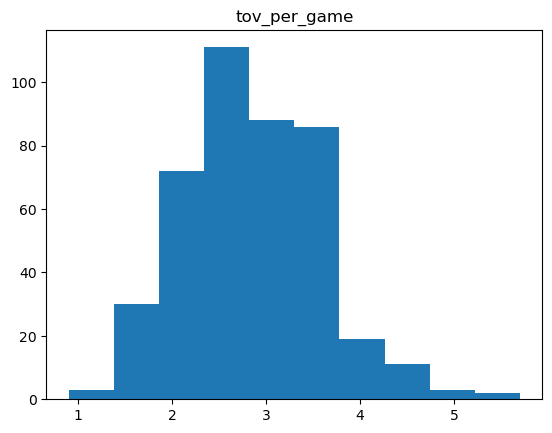

In [19]:
for i in numerical_cols:
    plt.hist(x=df_final[i])
    plt.title(i)
    plt.show()
    plt.close()

In [15]:
# What are the average basic statistics for MVP candidates?

In [20]:
df_final.groupby('winner')['ppg'].mean()

winner
False    22.565808
True     27.117241
Name: ppg, dtype: float64

In [17]:
# MVP winners on average have a higher PPG than other candidates

In [21]:
df_final.groupby('winner')['age'].mean()

winner
False    27.593434
True     27.517241
Name: age, dtype: float64

In [19]:
# No signicant difference in age among MVP candidates

In [22]:
df_final.groupby('winner')['assists'].mean()

winner
False    5.289495
True     6.386207
Name: assists, dtype: float64

In [21]:
# MVP winners have a slightly higher average in assists per game

In [24]:
df_final.groupby('winner')['steals'].mean()

winner
False    1.353131
True     1.413793
Name: steals, dtype: float64

In [25]:
# No significant difference in average steals per game

In [26]:
df_final.groupby('winner')['blocks'].mean()

winner
False    0.878384
True     0.965517
Name: blocks, dtype: float64

In [27]:
# MVPs don't seem to average a high number of blocks per game

In [28]:
df_final.groupby('winner')['rebounds'].mean()

winner
False    7.193586
True     8.713793
Name: rebounds, dtype: float64

In [29]:
# MVP winners seem to have a higher average number of rebounds per game

In [30]:
df_final.groupby('winner')['win%'].mean()

winner
False    0.631141
True     0.738545
Name: win%, dtype: float64

In [31]:
# In general, MVP winners are on winning teams

In [7]:
# Model is ready for training
X = df_final.drop(columns=['winner'])
y = df_final['winner']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
# Standard Scaler for Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [81]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [82]:
X_train = scaler.fit_transform(X_train)

In [83]:
X_test = scaler.fit_transform(X_test)

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
def modelperformance(y_pred):
    print('Accuracy score:', accuracy_score(y_test, y_pred),
         'F1 score:', f1_score(y_test, y_pred))

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()

In [51]:
log.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [52]:
y_pred = log.predict(X_test)
modelperformance(y_pred)

Accuracy score: 0.9647058823529412 F1 score: 0.7272727272727273


In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [48]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1,2]
}

In [49]:
gridkn = GridSearchCV(KNeighborsClassifier(),
    param_grid,
    scoring='accuracy',
    cv=5
)

In [50]:
gridkn.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


In [51]:
y_pred = gridkn.predict(X_test)
modelperformance(y_pred)

Accuracy score: 0.9529411764705882 F1 score: 0.6666666666666666


In [38]:
from sklearn.svm import SVC
svm = SVC(random_state=42)

In [39]:
param_grid = {
    'C': [0.01, 0.1, 0.5, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

In [40]:
gridsvm = GridSearchCV(svm, 
                       param_grid,
                       scoring='accuracy',
                       cv=5)

In [41]:
gridsvm.fit(X_train, y_train)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [42]:
y_pred = gridsvm.predict(X_test)
modelperformance(y_pred)

Accuracy score: 0.9529411764705882 F1 score: 0.7142857142857143


In [14]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

In [20]:
gridrf = GridSearchCV(RandomForestClassifier(random_state=42),
                      param_grid,
                      scoring='accuracy',
                      cv=5)

In [21]:
gridrf.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced'], 'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [22]:
y_pred = gridrf.predict(X_test)
modelperformance(y_pred)

Accuracy score: 0.9764705882352941 F1 score: 0.8333333333333334


In [68]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)

In [82]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.001, 0.01, 0.1],
    'scale_pos_weight': [1, 14]
}

In [83]:
gridxgb = GridSearchCV(xgb,
                       param_grid,
                       scoring='accuracy',
                       cv=5)

In [84]:
gridxgb.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.001, 0.01, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'scale_pos_weight': [1, 14]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [85]:
y_pred = gridxgb.predict(X_test)
modelperformance(y_pred)

Accuracy score: 0.9529411764705882 F1 score: 0.6


In [ ]:
# For purely speed reasons, XGBoost is less tuned for performance so RandomForest will be the model we use

In [52]:
best_features = gridrf.best_estimator_
importances = best_features.feature_importances_

feature_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances}).sort_values(by='importance', ascending=False)

In [53]:
print('Level of importance for each predictive variable:\n' , feature_df)

Level of importance for each predictive variable:
          feature  importance
5           vorp    0.134943
3          ws_48    0.111745
13          win%    0.101764
12             l    0.091682
2            per    0.084827
4            bpm    0.082489
18  tov_per_game    0.058890
7        assists    0.050859
6            ppg    0.050232
11             w    0.047165
14   fg_per_game    0.045388
17    ft_percent    0.027754
0         season    0.021365
1            age    0.018074
16           2pm    0.017334
10      rebounds    0.016247
8         steals    0.016181
9         blocks    0.011875
15           3pm    0.011188


In [ ]:
# Could we create an accurate model with just the top 5 features?

In [18]:
X2 = X[['vorp', 'ws_48', 'win%', 'l', 'per']]

In [19]:
X2

,vorp,ws_48,win%,l,per
0,10.6,0.299,0.6951,25.0,31.0
1,7.1,0.275,0.6951,25.0,29.3
2,8.0,0.220,0.6098,32.0,28.1
3,7.2,0.246,0.5976,33.0,29.9
4,5.4,0.198,0.6098,32.0,23.4
...,...,...,...,...,...
420,1.8,0.181,0.6463,29.0,21.1
421,4.2,0.178,0.5122,40.0,22.7
422,1.1,0.143,0.8780,10.0,13.6
423,6.2,0.237,0.5732,35.0,25.2


In [62]:
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

In [63]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

In [64]:
gridrf2 = GridSearchCV(RandomForestClassifier(random_state=42),
                      param_grid,
                      scoring='accuracy',
                      cv=5)

In [65]:
gridrf2.fit(X2_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced'], 'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [66]:
y_pred = gridrf2.predict(X2_test)
modelperformance(y_pred)

Accuracy score: 0.9647058823529412 F1 score: 0.7272727272727273


In [ ]:
# The new model is still quite accurate, even when compared to Logistic Regression with all features included

In [34]:
from sklearn import metrics

In [35]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)

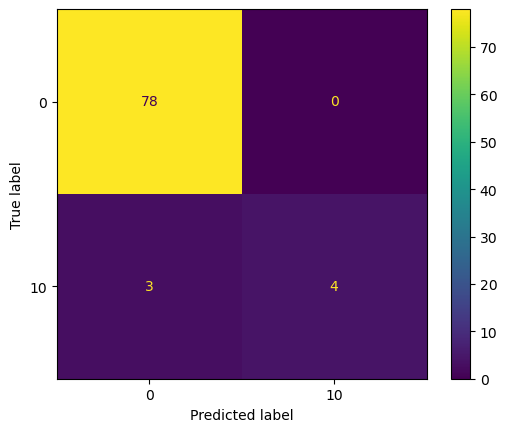

In [38]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 10])
cm_display.plot()
plt.show()

In [39]:
# True Negative (Top Left), True Positive (Bottom Right), False Positive (Top Right), False Negative (Bottom Left)

In [68]:
best_model = gridrf2.best_estimator_

In [69]:
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [ ]:
# Output our best model as a .pkl to be used in Streamlit